In [1]:
# ==========================================
# Setup: Imports & Configuration
# ==========================================

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet18_Weights
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import copy
import time
import pandas as pd
from sklearn.metrics import accuracy_score

# Set Seed for Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Create results directory
os.makedirs('results', exist_ok=True)

# Set style for  plots
sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
print("Libraries loaded.")

Libraries loaded.


Loading Pretrained ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.8MB/s]


Extracted Conv Layer: Layer2.0.Conv1
Tensor Shape: torch.Size([128, 64, 3, 3]) (Out=128, In=64, Kernel=3x3)
Reshaped 2D Matrix: torch.Size([128, 576])

--- Sensitivity Analysis for Conv_Layer_Layer2.0.Conv1 ---
Total Ranks (Full Rank): 128
[Threshold 90.0%]: k= 77 | New Params: 54208 | Ratio: 0.7352 | Saving: 26.48%
[Threshold 95.0%]: k= 94 | New Params: 66176 | Ratio: 0.8976 | Saving: 10.24%
[Threshold 99.0%]: k=118 | New Params: 83072 | Ratio: 1.1267 | Saving: -12.67%
Plot saved to: results/spectral_analysis_Conv_Layer_Layer2.0.Conv1.png


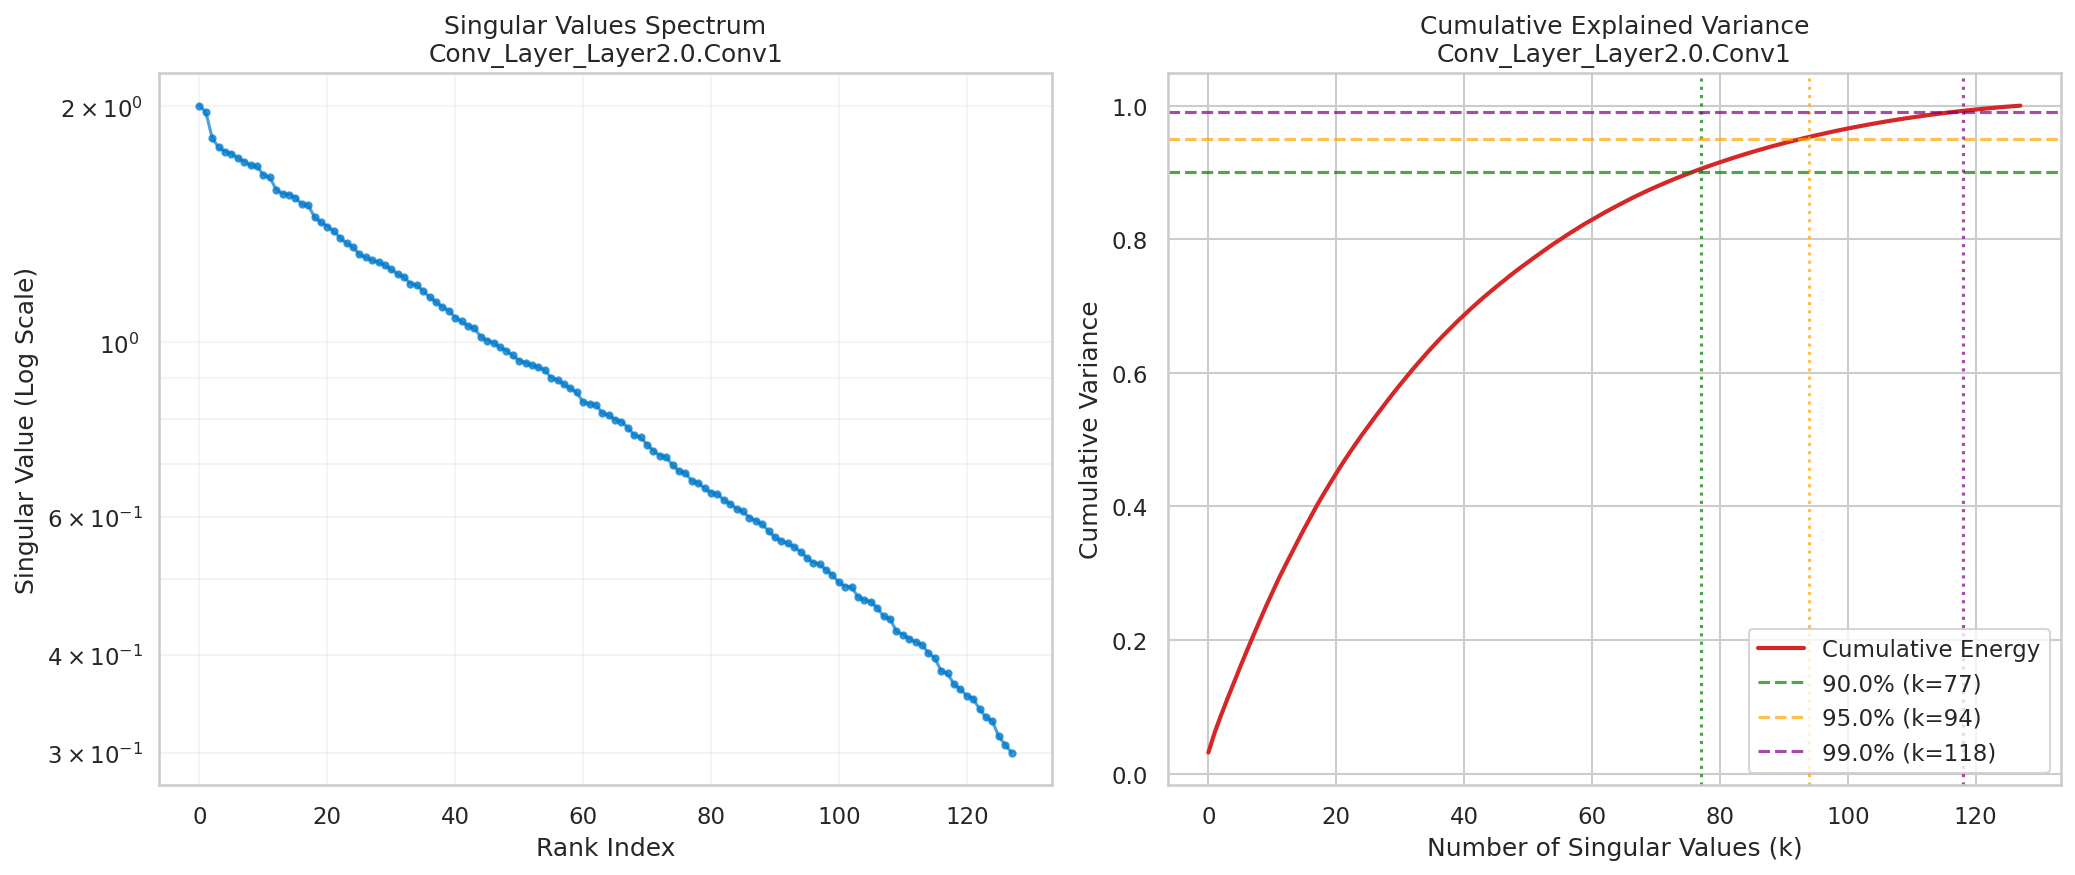

Extracted Linear Layer: FC
Matrix Shape: torch.Size([1000, 512])

--- Sensitivity Analysis for Fully_Connected_Layer_FC ---
Total Ranks (Full Rank): 512
[Threshold 90.0%]: k=231 | New Params: 349272 | Ratio: 0.6822 | Saving: 31.78%
[Threshold 95.0%]: k=291 | New Params: 439992 | Ratio: 0.8594 | Saving: 14.06%
[Threshold 99.0%]: k=410 | New Params: 619920 | Ratio: 1.2108 | Saving: -21.08%
Plot saved to: results/spectral_analysis_Fully_Connected_Layer_FC.png


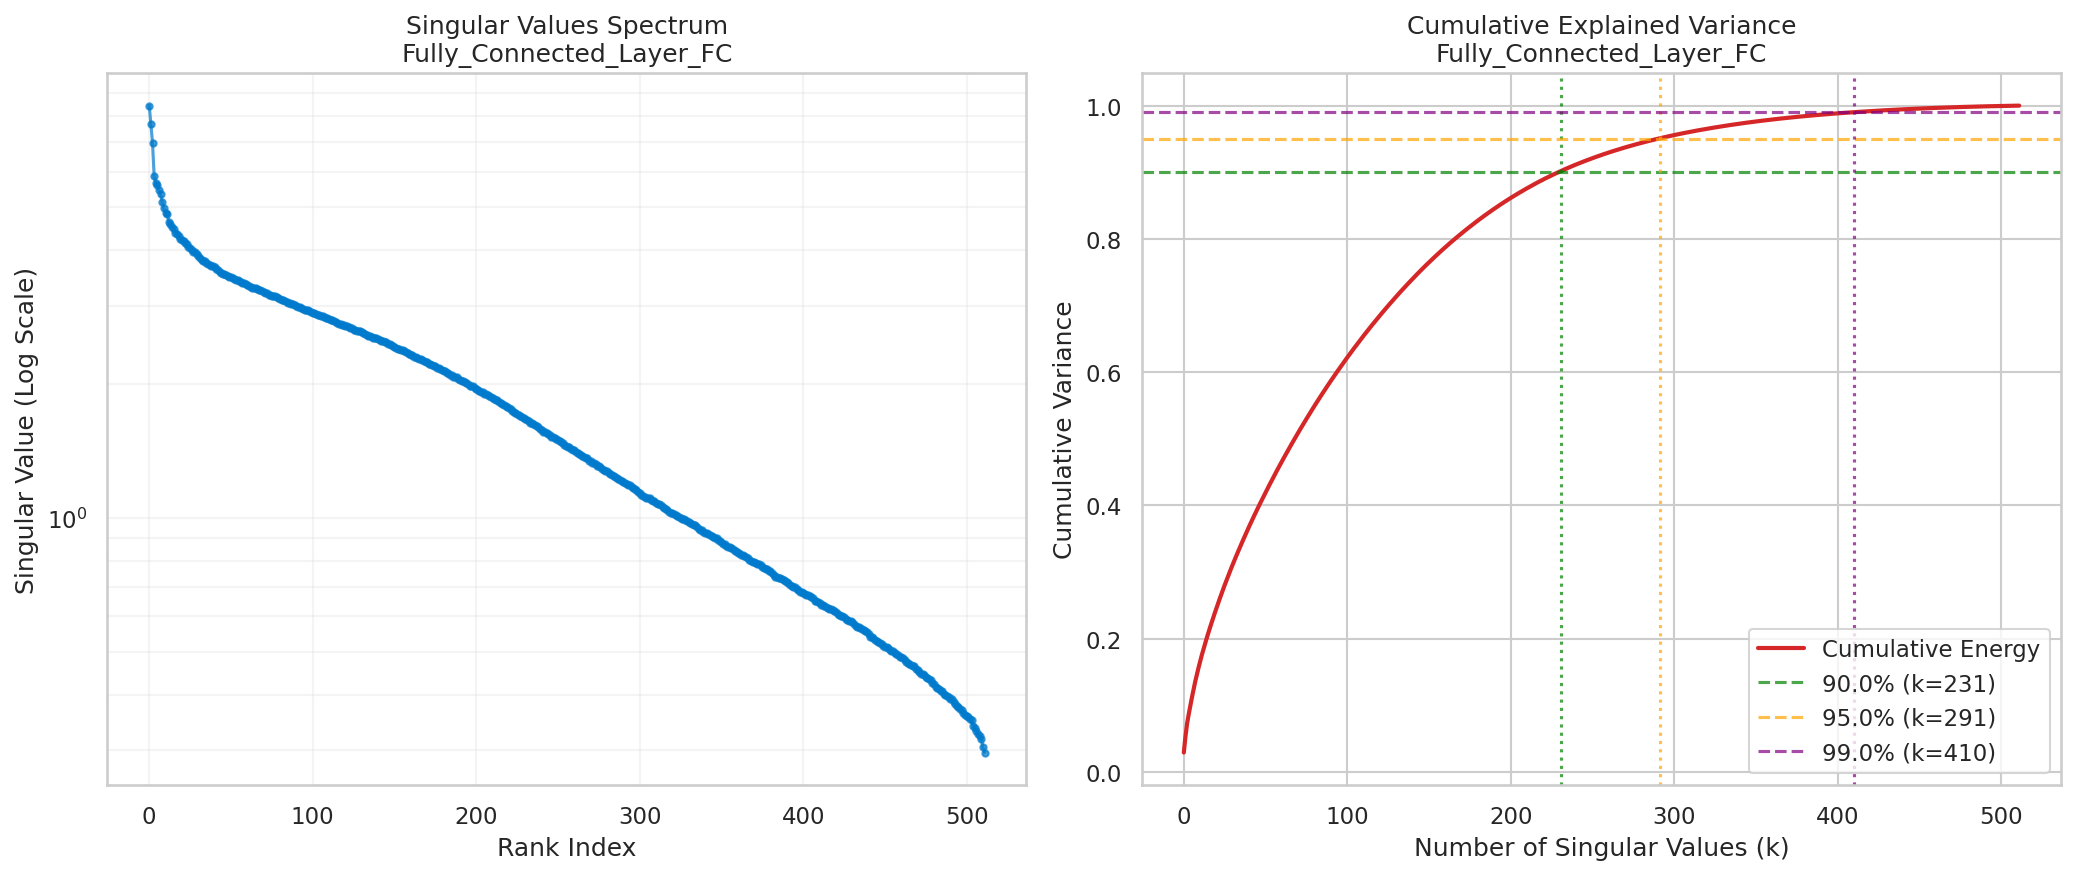

In [2]:
# ==========================================
# Part 1: Spectral Analysis of Model Weights
# ==========================================

def get_layer_weights(model, layer_type='conv'):
    """
    Extracts weights from a specific layer of the model.
    """
    if layer_type == 'conv':
        # Extracting a middle convolutional layer (e.g., layer2.0.conv1)
        weights = model.layer2[0].conv1.weight.detach().cpu()
        out_c, in_c, k_h, k_w = weights.shape

        print(f"Extracted Conv Layer: Layer2.0.Conv1")
        print(f"Tensor Shape: {weights.shape} (Out={out_c}, In={in_c}, Kernel={k_h}x{k_w})")

        # Reshape for SVD: (out_channels, in_channels * k * k)
        weights_2d = weights.view(out_c, -1)
        print(f"Reshaped 2D Matrix: {weights_2d.shape}")

        return weights_2d, "Conv_Layer_Layer2.0.Conv1"

    elif layer_type == 'fc':
        # Extracting the final fully connected layer
        weights = model.fc.weight.detach().cpu()
        print(f"Extracted Linear Layer: FC")
        print(f"Matrix Shape: {weights.shape}")
        return weights, "Fully_Connected_Layer_FC"

def analyze_singular_values(weights, layer_name_safe):
    """
    Performs SVD, analyzes sensitivity for multiple thresholds,
    calculates theoretical compression, and saves plots.
    """
    # Perform SVD
    U, S, V = torch.linalg.svd(weights, full_matrices=False)
    S_np = S.numpy()
    m, n = weights.shape
    original_params = m * n

    # Calculate Energy
    energy = S_np ** 2
    cumulative_energy = np.cumsum(energy) / np.sum(energy)
    total_ranks = len(S_np)

    print(f"\n--- Sensitivity Analysis for {layer_name_safe} ---")
    print(f"Total Ranks (Full Rank): {total_ranks}")

    # Sensitivity Analysis for different thresholds
    thresholds = [0.90, 0.95, 0.99]
    k_values = {}

    for thresh in thresholds:
        k = np.argmax(cumulative_energy >= thresh) + 1
        k_values[thresh] = k

        # Theoretical Compression Calculation
        # New params = U_k(m*k) + S_k(k) + V_k(n*k) -> approx k(m+n)
        new_params = k * (m + n)
        saving_ratio = (1 - (new_params / original_params)) * 100
        param_ratio = new_params / original_params

        print(f"[Threshold {thresh*100}%]: k={k:3d} | New Params: {new_params} | Ratio: {param_ratio:.4f} | Saving: {saving_ratio:.2f}%")

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Singular Values Spectrum
    ax1.plot(S_np, marker='.', linestyle='-', color='#007acc', alpha=0.7)
    ax1.set_yscale('log')
    ax1.set_title(f'Singular Values Spectrum\n{layer_name_safe}')
    ax1.set_xlabel('Rank Index')
    ax1.set_ylabel('Singular Value (Log Scale)')
    ax1.grid(True, which="both", ls="-", alpha=0.2)

    # Plot 2: Cumulative Variance
    ax2.plot(cumulative_energy, linewidth=2, color='#d62728', label='Cumulative Energy')

    colors = ['green', 'orange', 'purple']
    for idx, thresh in enumerate(thresholds):
        k = k_values[thresh]
        ax2.axhline(y=thresh, color=colors[idx], linestyle='--', alpha=0.7, label=f'{thresh*100}% (k={k})')
        ax2.axvline(x=k, color=colors[idx], linestyle=':', alpha=0.7)

    ax2.set_title(f'Cumulative Explained Variance\n{layer_name_safe}')
    ax2.set_xlabel('Number of Singular Values (k)')
    ax2.set_ylabel('Cumulative Variance')
    ax2.legend(loc='lower right')

    plt.tight_layout()
    save_path = f"results/spectral_analysis_{layer_name_safe}.png"
    plt.savefig(save_path)
    print(f"Plot saved to: {save_path}")
    plt.show()

# Main Execution
print("Loading Pretrained ResNet18...")
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.eval()

# Analyze Conv Layer
W_conv, name_conv = get_layer_weights(model, 'conv')
analyze_singular_values(W_conv, name_conv)

# Analyze FC Layer
W_fc, name_fc = get_layer_weights(model, 'fc')
analyze_singular_values(W_fc, name_fc)

In [3]:
# ==========================================
# Part 2: Practical Compression
# ==========================================

# Load and Prepare Data
print("Loading FashionMNIST Dataset...")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Use DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Data Loaded. Train Size: {len(train_dataset)}, Test Size: {len(test_dataset)}")

# 2. Define MLP Model
# Architecture: 784 -> 512 -> 256 -> 128 -> 10
class DeepFashionMLP(nn.Module):
    def __init__(self):
        super(DeepFashionMLP, self).__init__()
        self.flatten = nn.Flatten()

        # Layer 1: 784 -> 512
        self.layer1 = nn.Linear(28*28, 512)
        self.relu1 = nn.ReLU()

        # Layer 2: 512 -> 256
        self.layer2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()

        # Layer 3: 256 -> 128
        self.layer3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()

        # Output Layer: 128 -> 10
        self.output_layer = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.relu3(self.layer3(x))
        x = self.output_layer(x)
        return x

def train_model(model, loader, epochs=5, device='cpu',lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(loader):.4f}")
    return model

def evaluate_accuracy(model, loader, device='cpu'):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Compression Logic (Balanced SVD)
def compress_linear_layer(layer, compression_percentage):
    """
    Replaces a linear layer with low-rank approximation using Balanced SVD.
    """
    W = layer.weight.detach().cpu()
    bias = layer.bias.detach().cpu() if layer.bias is not None else None
    m, n = W.shape
    original_params = m * n

    keep_ratio = 1.0 - compression_percentage
    target_params = keep_ratio * original_params
    k = int(target_params / (m + n))
    k = max(1, k)

    # SVD
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    # Truncate
    U_k = U[:, :k]
    S_k = torch.diag(S[:k])
    Vh_k = Vh[:k, :]

    # Balanced Decomposition: W = (U * sqrt(S)) * (sqrt(S) * Vh)
    sqrt_S = torch.sqrt(S_k)
    W2 = torch.mm(U_k, sqrt_S)  # m x k
    W1 = torch.mm(sqrt_S, Vh_k) # k x n

    # Create new layers
    layer1 = nn.Linear(n, k, bias=False)
    layer1.weight.data = W1

    layer2 = nn.Linear(k, m, bias=(bias is not None))
    layer2.weight.data = W2
    if bias is not None:
        layer2.bias.data = bias

    return nn.Sequential(layer1, layer2), k, (m*n), k*(m+n)

# Run Experiment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("\n--- Training Initial Deep Fashion Model ---")
base_model = DeepFashionMLP()
base_model = train_model(base_model, train_loader, epochs=10, device=device)
acc_orig = evaluate_accuracy(base_model, test_loader, device=device)
params_orig = count_parameters(base_model)
print(f"Initial Accuracy: {acc_orig*100:.2f}%")
print(f"Total Parameters: {params_orig}")

results_summary = []
results_summary.append(['Original', 'N/A', 'N/A', 'N/A', params_orig, 0, f"{acc_orig*100:.2f}%"])

layers_to_compress = ['layer1', 'layer2', 'layer3']
compressed_models = {}

for comp_pct in [0.50, 0.80]:
    print(f"\n--- Testing {comp_pct*100:.0f}% Compression on All Hidden Layers ---")

    compressed_model = copy.deepcopy(base_model)
    compressed_model.to('cpu') # Move to CPU for SVD processing

    layer_details = []

    # Apply compression to all hidden layers
    for layer_name in layers_to_compress:
        original_layer = getattr(compressed_model, layer_name)
        new_layer, k, old_p, new_p = compress_linear_layer(original_layer, comp_pct)
        setattr(compressed_model, layer_name, new_layer)
        layer_details.append(f"{layer_name}: {old_p}->{new_p} (k={k})")

    # Evaluate (move back to device if needed, but for eval CPU is fine or device)
    acc_comp = evaluate_accuracy(compressed_model, test_loader, device=device)
    params_comp = count_parameters(compressed_model)
    saving_pct = (1 - params_comp/params_orig) * 100

    print(f"Accuracy: {acc_comp*100:.2f}%")
    print(f"Total Params: {params_comp} (Total Saving: {saving_pct:.2f}%)")
    print(f"Layer Details: {layer_details}")

    compressed_models[comp_pct] = compressed_model
    # Add to summary
    results_summary.append([
        f'Comp {comp_pct*100:.0f}%',
        layer_details[0],
        layer_details[1],
        layer_details[2],
        params_comp,
        f"{saving_pct:.2f}%",
        f"{acc_comp*100:.2f}%"
    ])

# Detailed Report Table
pd.set_option('display.max_colwidth', None)
df_res = pd.DataFrame(results_summary, columns=['Model', 'L1 Params', 'L2 Params', 'L3 Params', 'Total Params', 'Saving %', 'Accuracy'])
print("\nDetailed Comparison Table:")
print(df_res)

Loading FashionMNIST Dataset...


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.09MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 144kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.72MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.5MB/s]


Data Loaded. Train Size: 60000, Test Size: 10000
Using device: cpu

--- Training Initial Deep Fashion Model ---
Epoch 1/10, Loss: 0.5005
Epoch 2/10, Loss: 0.3743
Epoch 3/10, Loss: 0.3328
Epoch 4/10, Loss: 0.3058
Epoch 5/10, Loss: 0.2854
Epoch 6/10, Loss: 0.2683
Epoch 7/10, Loss: 0.2564
Epoch 8/10, Loss: 0.2411
Epoch 9/10, Loss: 0.2309
Epoch 10/10, Loss: 0.2190
Initial Accuracy: 88.33%
Total Parameters: 567434

--- Testing 50% Compression on All Hidden Layers ---
Accuracy: 88.31%
Total Params: 283178 (Total Saving: 50.09%)
Layer Details: ['layer1: 401408->199584 (k=154)', 'layer2: 131072->65280 (k=85)', 'layer3: 32768->16128 (k=42)']

--- Testing 80% Compression on All Hidden Layers ---
Accuracy: 87.77%
Total Params: 113882 (Total Saving: 79.93%)
Layer Details: ['layer1: 401408->79056 (k=61)', 'layer2: 131072->26112 (k=34)', 'layer3: 32768->6528 (k=17)']

Detailed Comparison Table:
      Model                       L1 Params                     L2 Params  \
0  Original                  


--- Phase 3: Fine-tuning and Speed Evaluation ---
Original Model Speed (CPU): 218.2543 ms/batch

Fine-tuning 50% Compressed Model...
Starting Fine-tuning...
Epoch 1/4, Loss: 0.1779
Epoch 2/4, Loss: 0.1581
Epoch 3/4, Loss: 0.1474
Epoch 4/4, Loss: 0.1390
Accuracy: 87.99% -> 89.70% (Improvement: 1.71%)
Inference Speed (CPU): 212.6897 ms/batch (Speedup: 1.03x)

Fine-tuning 80% Compressed Model...
Starting Fine-tuning...
Epoch 1/4, Loss: 0.1984
Epoch 2/4, Loss: 0.1831
Epoch 3/4, Loss: 0.1753
Epoch 4/4, Loss: 0.1692
Accuracy: 87.77% -> 89.81% (Improvement: 2.04%)
Inference Speed (CPU): 209.6121 ms/batch (Speedup: 1.04x)

Accuracy Plot saved to: results/accuracy_vs_compression.png


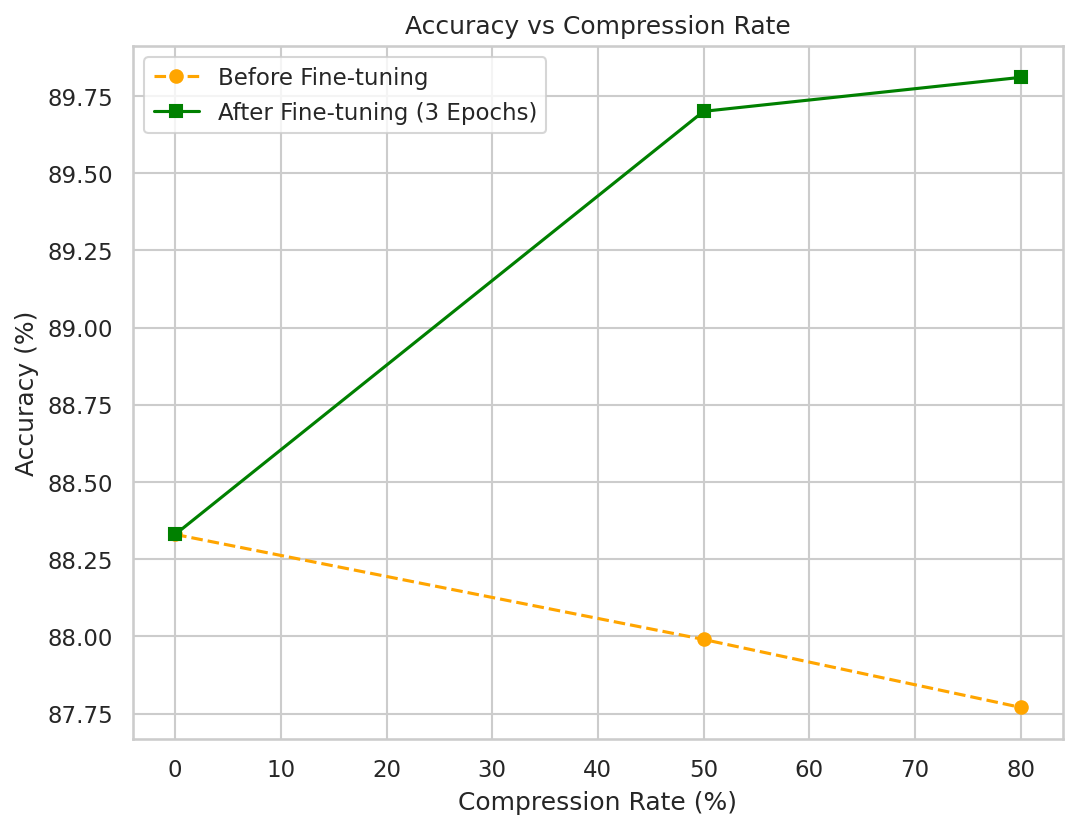


Final Performance Comparison:
            Model  Inference Time (ms/batch)   Speedup  Final Accuracy
0        Original                 218.254280  1.000000           88.33
1  Compressed 50%                 212.689662  1.026163           89.70
2  Compressed 80%                 209.612083  1.041229           89.81


In [ ]:
# ==========================================
# Part 3: Accuracy Recovery and Speed Evaluation (FashionMNIST)
# ==========================================

def measure_inference_speed(model, loader, device='cpu', n_batches=20):
    """Measures average inference time on CPU for a number of batches."""
    model.to(device)
    model.eval()

    # Warmup
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= 5: break
            images = images.to(device)
            _ = model(images)

    start_time = time.time()
    count = 0
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= n_batches: break
            images = images.to(device)
            _ = model(images)
            count += 1

    end_time = time.time()

    avg_time = (end_time - start_time) / count
    return avg_time * 1000  # Convert to milliseconds per batch

# Fine-tuning Compressed Models
print("\n--- Phase 3: Fine-tuning and Speed Evaluation ---")
finetuned_accuracies = []
inference_times = []

# For plotting
compression_rates = [0.0, 0.50, 0.80] # 0.0 is original
accuracies_before = [acc_orig * 100]
accuracies_after = [acc_orig * 100]

# Measure Original Model Speed on CPU
t_orig = measure_inference_speed(base_model, test_loader, device='cpu')
inference_times.append(t_orig)
print(f"Original Model Speed (CPU): {t_orig:.4f} ms/batch")

for comp_pct in [0.50, 0.80]:
    print(f"\nFine-tuning {comp_pct*100:.0f}% Compressed Model...")
    model = compressed_models[comp_pct]

    # Accuracy Before Fine-tuning
    acc_before = evaluate_accuracy(model, test_loader, device=device) * 100
    accuracies_before.append(acc_before)

    # Fine-tune for 4 epochs
    print("Starting Fine-tuning...")
    model = train_model(model, train_loader, epochs=4, device=device, lr=0.0001)

    # Accuracy After Fine-tuning
    acc_after = evaluate_accuracy(model, test_loader, device=device) * 100
    accuracies_after.append(acc_after)

    # Measure Speed on CPU
    t_comp = measure_inference_speed(model, test_loader, device='cpu')
    inference_times.append(t_comp)

    print(f"Accuracy: {acc_before:.2f}% -> {acc_after:.2f}% (Improvement: {acc_after - acc_before:.2f}%)")
    print(f"Inference Speed (CPU): {t_comp:.4f} ms/batch (Speedup: {t_orig/t_comp:.2f}x)")

# Plot Accuracy vs Compression Rate
plt.figure(figsize=(8, 6))
plt.plot([c * 100 for c in compression_rates], accuracies_before, marker='o', linestyle='--', label='Before Fine-tuning', color='orange')
plt.plot([c * 100 for c in compression_rates], accuracies_after, marker='s', linestyle='-', label='After Fine-tuning (3 Epochs)', color='green')
plt.title('Accuracy vs Compression Rate')
plt.xlabel('Compression Rate (%)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
save_path = "results/accuracy_vs_compression.png"
plt.savefig(save_path)
print(f"\nAccuracy Plot saved to: {save_path}")
plt.show()

# Speed Comparison Table
speed_data = {
    'Model': ['Original', 'Compressed 50%', 'Compressed 80%'],
    'Inference Time (ms/batch)': inference_times,
    'Speedup': [1.0] + [t_orig/t for t in inference_times[1:]],
    'Final Accuracy': accuracies_after
}
df_speed = pd.DataFrame(speed_data)
print("\nFinal Performance Comparison:")
print(df_speed)

In [9]:
# ==========================================
# Part 4: Analytical Question - Condition Number Analysis
# ==========================================

def analyze_condition_number(weights, layer_name):
    """
    Calculates the condition number of a weight matrix.
    Condition Number (Kappa) = sigma_max / sigma_min
    """
    # Compute Singular Values
    U, S, V = torch.linalg.svd(weights, full_matrices=False)

    sigma_max = S[0].item()
    sigma_min = S[-1].item()

    if sigma_min == 0:
        condition_number = float('inf')
    else:
        condition_number = sigma_max / sigma_min

    print(f"\n--- Condition Number Analysis: {layer_name} ---")
    print(f"Sigma Max: {sigma_max:.4f}")
    print(f"Sigma Min: {sigma_min:.4f}")
    print(f"Condition Number (Kappa): {condition_number:.2f}")

    return condition_number

print("\nCalculating Condition Numbers for DeepFashionMLP Layers...")
layers_to_analyze = ['layer1', 'layer2', 'layer3']
base_model.to('cpu') # Ensure model is on CPU

for layer_name in layers_to_analyze:
    layer = getattr(base_model, layer_name)
    weights = layer.weight.detach()
    cond_num = analyze_condition_number(weights, layer_name)




Calculating Condition Numbers for DeepFashionMLP Layers...

--- Condition Number Analysis: layer1 ---
Sigma Max: 14.2646
Sigma Min: 0.1525
Condition Number (Kappa): 93.57

--- Condition Number Analysis: layer2 ---
Sigma Max: 7.5191
Sigma Min: 0.2725
Condition Number (Kappa): 27.59

--- Condition Number Analysis: layer3 ---
Sigma Max: 4.0880
Sigma Min: 0.2398
Condition Number (Kappa): 17.05
